# FinTok AI · 03_image / 01 · Avatares cartoon

**Objetivo:** convertir una foto de cada una de nosotras en un avatar de dibujo animado, con dos versiones (boca cerrada y boca abierta) y fondo transparente. El montador de vídeo alternará entre ambas según el volumen del audio para que parezca que el avatar habla.

**Modelos:**
- **SDXL Turbo** (image-to-image, como en el notebook 4 de clase): redibuja la foto en estilo cartoon.
- **rembg (U²-Net)**: recorta el fondo para poder poner el avatar encima de cualquier escena.

**Entrada:** una foto frontal por persona (cara bien iluminada, boca cerrada, fondo sencillo).

**Salida** (en `assets/avatar/`):
- `<persona>_closed.png` y `<persona>_open.png` (RGBA, 512×512)
- `<persona>_preview.gif` (comprobación rápida)
- `<persona>_meta.json` (prompt, strength y seed usados, para reproducibilidad)

**Cómo usarlo:** Entorno de ejecución → Cambiar tipo → **GPU T4**. Ejecuta el notebook con `PERSONA = "andrea"`, y luego cambia a la otra persona y vuelve a ejecutar desde la sección 2.

> Las funciones de este notebook pasarán después a `src/image/avatar.py`.

## 0. Instalación

In [4]:
!pip install -q diffusers transformers accelerate rembg onnxruntime

KeyboardInterrupt: 

## 1. Imports, configuración y modelo

In [5]:
img2img = AutoPipelineForImage2Image.from_pretrained(
    "stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16"
).to("cuda")

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

In [6]:
import os, json
import torch
from PIL import Image, ImageOps, ImageDraw, ImageFilter
from IPython.display import display, Image as IPImage
from diffusers import AutoPipelineForImage2Image

AVATAR_DIR = "assets/avatar"
os.makedirs(AVATAR_DIR, exist_ok=True)
SIZE = 512  # SDXL Turbo está entrenado a 512x512

## 2. Elegir persona y subir su foto

In [9]:
PERSONA = "andrea"        # cambia a "companera" en la segunda pasada
DESCRIPCION = "young woman with long curly light brown hair and brown eyes"   # rasgos para ayudar al modelo a parecerse

In [10]:
from google.colab import files
uploaded = files.upload()          # sube la foto de PERSONA
FOTO = list(uploaded.keys())[0]
print("Foto:", FOTO)

Saving IMG_6463 2.JPG to IMG_6463 2 (2).JPG
Foto: IMG_6463 2 (2).JPG


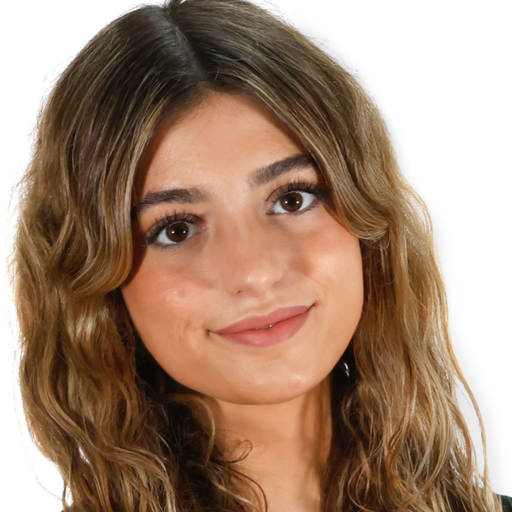

In [11]:
def load_portrait(path, size=SIZE, zoom=1.8, center=(0.47, 0.32)):
    """zoom: cuánto acercar (1 = imagen completa). center: posición de la cara (x, y) en proporción."""
    img = ImageOps.exif_transpose(Image.open(path)).convert("RGB")
    w, h = img.size
    side = int(min(w, h) / zoom)
    cx, cy = int(center[0] * w), int(center[1] * h)
    left = max(0, min(w - side, cx - side // 2))
    top = max(0, min(h - side, cy - side // 2))
    return img.crop((left, top, left + side, top + side)).resize((size, size), Image.LANCZOS)

foto = load_portrait(FOTO)
display(foto)

## 3. Generar el avatar cartoon (boca cerrada)

Probamos varias combinaciones de `strength` (cuánto se aleja de la foto) y `seed` (variación aleatoria):
- `strength` bajo → se parece más a la foto, menos cartoon.
- `strength` alto → más cartoon, menos parecido.

Con `guidance_scale=0.0` y 4 pasos, como indica el notebook de clase.

In [12]:
STYLE_PROMPT = (
    "Pixar Disney 3D animation style, cartoon character, stylized CGI render, "
    "big expressive eyes, smooth skin, {desc}, financial analyst wearing a navy blazer, "
    "{mouth}, looking at the camera, head and shoulders, soft studio lighting, "
    "plain light grey background, 3D cartoon"
)
PROMPT_CLOSED = STYLE_PROMPT.format(desc=DESCRIPCION, mouth="friendly smile with closed mouth")

def generate_variants(image, prompt, strengths=(0.45, 0.65, 0.85), seeds=(0, 1, 2), steps=4):
    results = []
    for s in strengths:
        for seed in seeds:
            g = torch.Generator("cuda").manual_seed(seed)
            out = img2img(prompt=prompt, image=image, strength=s, guidance_scale=0.0,
                          num_inference_steps=steps, generator=g).images[0]
            results.append({"strength": s, "seed": seed, "image": out})
    return results

def show_grid(results, cols=3, thumb=256):
    rows = (len(results) + cols - 1) // cols
    grid = Image.new("RGB", (cols * thumb, rows * (thumb + 24)), "white")
    d = ImageDraw.Draw(grid)
    for i, r in enumerate(results):
        x, y = (i % cols) * thumb, (i // cols) * (thumb + 24)
        grid.paste(r["image"].resize((thumb, thumb)), (x, y + 24))
        d.text((x + 5, y + 5), f"#{i}  strength={r['strength']}  seed={r['seed']}", fill="black")
    display(grid)

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


  0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl_img2img.py:896: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()`

  0%|          | 0/1 [00:00<?, ?it/s]

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


...

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


  0%|          | 0/3 [00:00<?, ?it/s]

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


  0%|          | 0/3 [00:00<?, ?it/s]

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


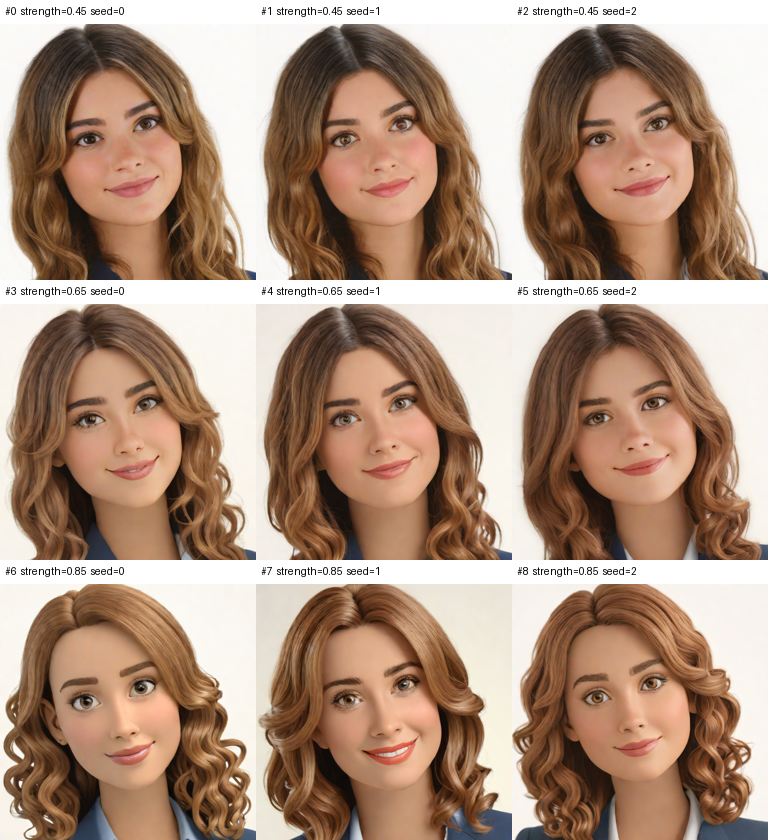

In [13]:
variants_closed = generate_variants(foto, PROMPT_CLOSED)
show_grid(variants_closed)

Elige el número (`#`) del que más te guste. Si ninguno convence, cambia `DESCRIPCION`, los `strengths` o las `seeds` y vuelve a ejecutar la celda anterior.

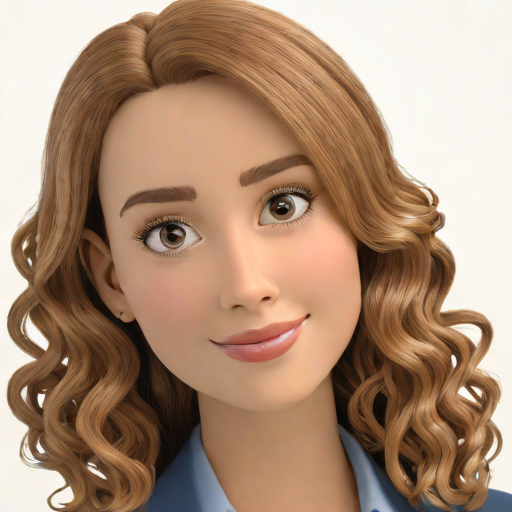

In [22]:
ELEGIDO_CLOSED = 6
closed = variants_closed[ELEGIDO_CLOSED]["image"]
display(closed)

In [24]:
import gc
del img2img
gc.collect()
torch.cuda.empty_cache()

NameError: name 'img2img' is not defined

## 4. Versión con la boca abierta

Para que el avatar parezca que habla necesitamos una segunda imagen idéntica con la boca abierta. Los modelos de difusión no conseguían cambiar la expresión de forma fiable, así que:

1. **Detectamos la boca automáticamente** con un modelo de landmarks faciales (face-alignment, 68 puntos).
2. **Abrimos la boca con una deformación geométrica**: bajamos el labio inferior y la barbilla y rellenamos el hueco con el interior de la boca.

Así el resto de la cara queda idéntico y el proceso es reproducible para cualquier avatar.

### 4.1 Localizar la boca

La rejilla marca los píxeles cada 32 (las líneas rojas fuertes, cada 128). Ajusta `MOUTH_BOX = (x0, y0, x1, y1)` hasta que el óvalo verde cubra la boca, con algo de margen por debajo (al abrir la boca baja la barbilla).

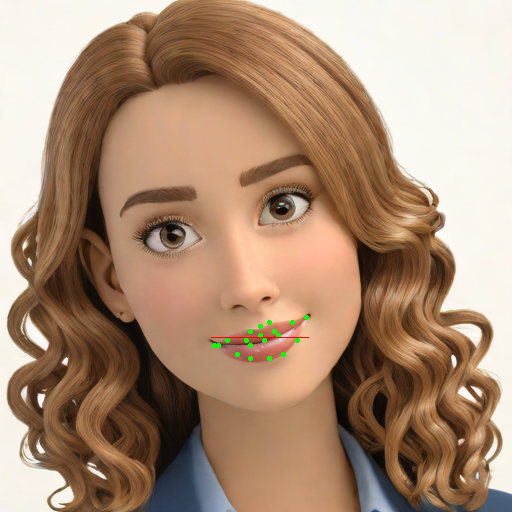

{'cx': 260.0, 'lip_y': 337.5, 'mouth_w': 96.167, 'tilt': -0.304}


In [25]:
import numpy as np, cv2
import face_alignment

fa = face_alignment.FaceAlignment(face_alignment.LandmarksType.TWO_D, device="cuda")

def detect_mouth(img):
    """Localiza la boca con 68 landmarks faciales (puntos 48-67 = boca)."""
    preds = fa.get_landmarks(np.array(img.convert("RGB")))
    if not preds:
        raise ValueError("No se ha detectado ninguna cara.")
    pts = preds[0]
    left, right = sorted([pts[48], pts[54]], key=lambda p: p[0])
    upper_inner, lower_inner = pts[62], pts[66]
    return {
        "cx": float((left[0] + right[0]) / 2),
        "lip_y": float((upper_inner[1] + lower_inner[1]) / 2),
        "mouth_w": float(np.hypot(right[0] - left[0], right[1] - left[1])),
        "tilt": float((right[1] - left[1]) / (right[0] - left[0])),
        "landmarks": pts[48:68].tolist(),
    }

def show_landmarks(img, mouth):
    im = img.copy().convert("RGB")
    d = ImageDraw.Draw(im)
    for x, y in mouth["landmarks"]:
        d.ellipse((x - 2, y - 2, x + 2, y + 2), fill="lime")
    cx, y = mouth["cx"], mouth["lip_y"]
    d.line((cx - mouth["mouth_w"] / 2, y, cx + mouth["mouth_w"] / 2, y), fill="red")
    display(im)

mouth = detect_mouth(closed)
show_landmarks(closed, mouth)
print({k: round(v, 3) for k, v in mouth.items() if k != "landmarks"})

### 4.2 Generar la boca abierta (inpainting)

Creamos una máscara con la zona de la boca (blanco = se redibuja, negro = se conserva) y pedimos al modelo que la rellene con una boca abierta. Probamos varias combinaciones de `strength` y `seed`.

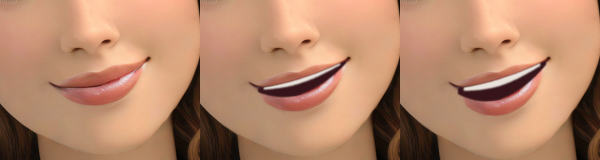

In [33]:
def open_mouth_warp(img, mouth, drop_ratio=0.22, teeth=True, ss=4):
    """Abre la boca usando los landmarks: baja el labio inferior y la barbilla y rellena
    el hueco siguiendo el contorno interior real de los labios."""
    cx, lip_y, mw, tilt = mouth["cx"], mouth["lip_y"], mouth["mouth_w"], mouth["tilt"]
    drop = mw * drop_ratio
    arr = np.array(img.convert("RGB")).astype(np.float32)
    h, w = arr.shape[:2]
    ys, xs = np.mgrid[0:h, 0:w].astype(np.float32)
    sigma = mw * 0.45
    wx_f = lambda x: np.exp(-((x - cx) / sigma) ** 2)
    t = ys - (lip_y + tilt * (xs - cx))
    disp = drop * wx_f(xs) * np.clip(t / drop, 0, 1) * np.exp(-np.clip(t - drop, 0, None) / (drop * 4))
    warped = cv2.remap(arr, xs, ys - disp, cv2.INTER_LINEAR, borderMode=cv2.BORDER_REFLECT)
    out = Image.fromarray(warped.clip(0, 255).astype(np.uint8))

    lm = np.array(mouth["landmarks"], dtype=np.float64)   # puntos 48-67
    inner = lm[12:20]                                     # 60-67: contorno interior de los labios
    upper = inner[[0, 1, 2, 3, 4]]                        # labio de arriba, de izquierda a derecha
    lower = inner[[4, 5, 6, 7, 0]].copy()                 # labio de abajo, de derecha a izquierda
    lower[:, 1] += drop * wx_f(lower[:, 0])               # el labio inferior baja con la deformación

    def smooth(pts, n=60):
        """Curva suave que pasa cerca de los puntos."""
        coef = np.polyfit(pts[:, 0], pts[:, 1], 2)
        x = np.linspace(pts[0, 0], pts[-1, 0], n)
        return np.stack([x, np.polyval(coef, x)], 1)

    poly = np.vstack([smooth(upper), smooth(lower)])

    # dibujar a mayor resolución para bordes suaves
    W, H = w * ss, h * ss
    layer = Image.new("RGB", (W, H), (55, 20, 26))
    mask = Image.new("L", (W, H), 0)
    ImageDraw.Draw(mask).polygon([tuple(p * ss) for p in poly], fill=255)
    if teeth:
        top = smooth(upper)[4:-4]
        bottom = top.copy()
        bottom[:, 1] += drop * wx_f(top[:, 0]) * 0.50
        tm = Image.new("L", (W, H), 0)
        ImageDraw.Draw(tm).polygon([tuple(p * ss) for p in np.vstack([top, bottom[::-1]])], fill=255)
        tm = tm.filter(ImageFilter.GaussianBlur(ss * 0.8))
        layer = Image.composite(Image.new("RGB", (W, H), (232, 226, 218)), layer, tm)
    layer = layer.resize((w, h), Image.LANCZOS)
    mask = mask.filter(ImageFilter.GaussianBlur(ss * 0.7)).resize((w, h), Image.LANCZOS)
    return Image.composite(layer, out, mask)

DROP_HALF, DROP_OPEN = 0.10, 0.15

half = open_mouth_warp(closed, mouth, drop_ratio=DROP_HALF)
opened = open_mouth_warp(closed, mouth, drop_ratio=DROP_OPEN)

c = (int(mouth["cx"]), int(mouth["lip_y"]))
box = (c[0] - 100, c[1] - 80, c[0] + 100, c[1] + 80)
row = Image.new("RGB", (600, 160))
for i, im in enumerate([closed, half, opened]):
    row.paste(im.crop(box).resize((200, 160)), (i * 200, 0))
display(row)

## 5. Quitar el fondo

Calculamos la silueta **una sola vez** sobre la versión cerrada y la aplicamos a las dos, para que el contorno sea idéntico.

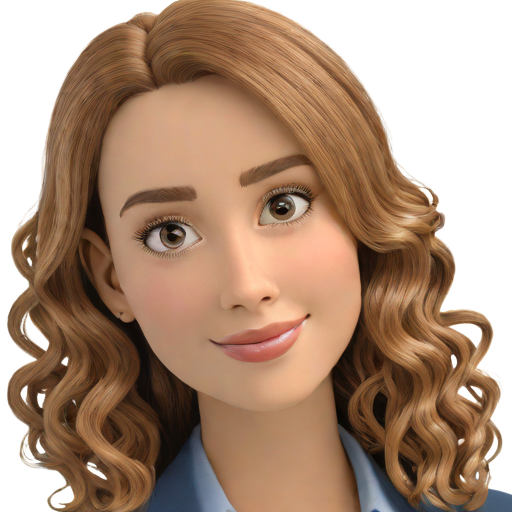

In [34]:
from rembg import remove

alpha = remove(closed).split()[-1]
def with_alpha(im):
    im = im.convert("RGBA"); im.putalpha(alpha); return im

closed_rgba, half_rgba, open_rgba = with_alpha(closed), with_alpha(half), with_alpha(opened)
display(closed_rgba)

## 6. Vista previa animada

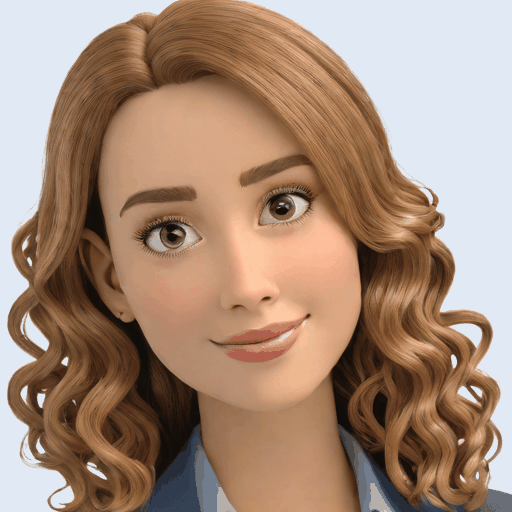

In [28]:
base = Image.new("RGBA", closed_rgba.size, (225, 233, 245, 255))
fc, fh, fo = [Image.alpha_composite(base, im).convert("RGB") for im in (closed_rgba, half_rgba, open_rgba)]
secuencia = [fc, fh, fo, fh, fc, fo, fh, fc, fc, fh, fo, fo, fh, fc] * 3
gif_path = f"{AVATAR_DIR}/{PERSONA}_preview.gif"
secuencia[0].save(gif_path, save_all=True, append_images=secuencia[1:], duration=90, loop=0)
display(IPImage(filename=gif_path))

## 7. Guardar

In [35]:
closed_rgba.save(f"{AVATAR_DIR}/{PERSONA}_closed.png")
open_rgba.save(f"{AVATAR_DIR}/{PERSONA}_open.png")
half_rgba.save(f"{AVATAR_DIR}/{PERSONA}_half.png")

meta = {
    "persona": PERSONA,
    "model": "stabilityai/sdxl-turbo (img2img)",
    "prompt_closed": PROMPT_CLOSED,
    "closed": {k: variants_closed[ELEGIDO_CLOSED][k] for k in ("strength", "seed")},
    "mouth_detection": "face-alignment (68 landmarks)",
    "mouth": {k: v for k, v in mouth.items() if k != "landmarks"} | {"drop_ratio": DROP_RATIO},
    "background_removal": "rembg (U2-Net)",
}

with open(f"{AVATAR_DIR}/{PERSONA}_meta.json", "w") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print(sorted(os.listdir(AVATAR_DIR)))

['andrea_closed.png', 'andrea_half.png', 'andrea_meta.json', 'andrea_open.png', 'andrea_preview.gif']


Cuando tengas los avatares de las dos, descarga la carpeta y súbela a `assets/avatar/` en el repo.

In [36]:
!zip -qr avatars.zip assets/avatar
files.download("avatars.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>